In [116]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [117]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-03-20 16:20:00--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.4’

names.txt.4         100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-03-20 16:20:00 (12.5 MB/s) - ‘names.txt.4’ saved [228145/228145]



In [118]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [119]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [120]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [121]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [122]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [123]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
Xb.shape, Yb.shape

(torch.Size([32, 3]), torch.Size([32]))

In [124]:
emb = C[Xb] # embed characters into vectors         # [32, 3, 10]
embcat = emb.view(emb.shape[0], -1)                 # [32, 30]   # concatenate the vectors
# Linear Layer 1
hprebn = embcat @ W1 + b1                           # [32, 64]
# Batch norm
bnmeani = (1/n) * hprebn.sum(dim=0, keepdim=True)   # [1, 64]
bndiff = hprebn - bnmeani                           # [32, 64]
bndiff2 = bndiff ** 2                               # [32, 64]
bnvar = (1/(n-1)) * bndiff2.sum(dim=0, keepdim=True)# [1, 64]    # Bessel's correction: dividing by n-1 instead of n
bnvar_inv = (bnvar + 1e-5)**-0.5                    # [1, 64]
bnraw = bndiff * bnvar_inv                          # [32, 64]
hpreact = bngain*bnraw + bnbias                     # [32, 64]
# Tanh
h = torch.tanh(hpreact)                             # [32, 64]
# Linear Layer 2
logits = h @ W2 + b2                                # [32, 27]
logit_maxes = logits.max(dim=1, keepdim=True).values# [32, 1]
norm_logits = logits - logit_maxes                  # [32, 27] # subtract max for numerical stability
counts = norm_logits.exp()                          # [32, 27]
counts_sum = counts.sum(dim=1, keepdim=True)        # [32, 1]
counts_sum_inv = counts_sum ** -1                   # [32, 1]
probs = counts * counts_sum_inv                     # [32, 27]
logprobs = probs.log()                              # [32, 27]
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3305, grad_fn=<NegBackward0>)

In [125]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

# -----------------
# YOUR CODE HERE :)
# -----------------
dlogprobs = torch.zeros_like(logprobs)                              # [32, 27]
dlogprobs[range(n), Yb] = -1/n

dprobs = (1/probs)*dlogprobs                                        # [32, 27]

dcounts_sum_inv = (counts * dprobs).sum(dim=1, keepdim=True)        # [32, 27] -> [32, 1]

dcounts_sum = -(counts_sum)**-2 * dcounts_sum_inv                   # [32, 1]

# Branch 1
dcounts = counts_sum_inv * dprobs                                   # [32, 27]
# Branch 2
dcounts += torch.ones_like(counts) * dcounts_sum                    # [32, 27]

dnorm_logits = counts * dcounts                                     # [32, 27]

dlogit_maxes = (-torch.ones_like(logit_maxes) * dnorm_logits).sum(dim=1, keepdim=True)  # [32, 27] -> [32, 1]

# Branch1
dlogits = dnorm_logits.clone()                                      # [32, 27]
# Branch2
dlogits += (logits == logit_maxes).float() * dlogit_maxes           # [32*27]*[32,1] -> [32, 27]

# W2 [64, 27] logits[32, 27] h[32, 64] b2 = 27
dh = dlogits @ W2.T                                                 # [32, 64]

dW2 = h.T @ dlogits                                                 # [64, 27]

db2 = dlogits.sum(dim=0)                                            # [1, 27]

dhpreact = (1-h**2) * dh                                            # [32, 64]

dbngain = (bnraw * dhpreact).sum(dim=0, keepdim=True)               # [32, 64] * [32, 64] -> [1, 64]

dbnbias = dhpreact.sum(dim=0, keepdim=True)                         # [32, 64] -> [1, 64]

dbnraw = bngain * dhpreact                                          # [32, 64]

dbnvar_inv = (bndiff * dbnraw).sum(dim=0, keepdim=True)             # [1, 64]

dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv                   # [1, 64]

dbndiff2 = ((1.0/(n-1))*torch.ones_like(bndiff2)) * dbnvar          # [32, 64] * [1, 64] -> [32, 64]

# Branch 1
dbndiff =  bnvar_inv * dbnraw                                       # [1, 64] * [32, 64] -> [32, 64]
# Branch 2
dbndiff += (2*bndiff) * dbndiff2                                    # [32, 64]

dbnmeani = (-dbndiff).sum(dim=0, keepdim=True)                      # [1, 64]

# Branch1
dhprebn = dbndiff.clone()                                           # [32, 64]
# Branch2
dhprebn += (1/n) * dbnmeani                                         # [32, 64] + [1, 64] -> [32, 64]

dembcat = dhprebn @ W1.T                                            # [32, 30]

dW1 = embcat.T @ dhprebn                                            # [30, 64]

db1 = dhprebn.sum(dim=0)                                            # [64]

demb = dembcat.view(emb.shape)                                      # [32, 3, 10]

dC = torch.zeros_like(C)                                            # [32, 27]
# For each example in batch, we can get index into C rows X(i, j) e.g. 1, 1, 4
# each of those index, gives a [10] vector corresponding to row vector in C
# Add to that row in C for which we get 10 embedding vector
for i in range(Xb.shape[0]):
  for j in range(Xb.shape[1]): # Gives row indices of C
    idx = Xb[i,j] # X[0,2] = 4
    dC[idx] += demb[i, j] # gives row in C                                                   # [32, 27]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
bngain          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnbias          | exact: False | approximate: True  | maxdiff: 2.3283064365386963e-09
bnraw  

In [126]:
# Understanding for h@W
# h [32, 64] W2 [64, 27] b2 [27]

# a [2x3]
#  [ [a11, a12, a13]
#    [a21, a22, a23] ]
# b [3x1]
#  [ [b1]
#    [b2]
#    [b3] ]
# c = a @ b
# [ [a11*b1 + a12*b2 + a13*b3]
#   [a21*b1 + a22*b2 + a23*b3] ]
#
# dc/da (Broadcast first) #Looks like transpose of b
# [ [b1, b2, b3],
#   [b1, b2, b3]]

In [127]:
# a= [[a11, a12, a13], [a21, a22, a23]]) # [2,3] (counts)
# b = [[b1], [b2]])                      # [2,1] (counts_sum_inv)
# c = a*b
# [a11*b1, a12*b1, a13*b1]
# [a21*b2, a22*b2, a23*b2]

# Sum (dim=1)
# a = [[1, 1, 1], [2, 2, 2]]
# b = [[1+1+1],   [2+2+2]]
# db/da (b broadcast happens first)
# [ [1+1+1, 1+1+1, 1+1+1],
#   [2+2+2, 2+2+2, 2+2+2] ]

# Sum (dim=0)
# a = [ [1, 1, 1],       [2x3]
#       [2, 3, 4] ]
# b = [[1+2, 1+3, 1+4]]  [1x3]
# db/da (b broadcast happens first)
#     [ [1, 1, 1]
#       [1, 1, 1] ]

# Logits Max
# a = [[1, 0, 5], [2, 9, 1]]
# b = [[5],       [9]]
# db/da (b broadcast happens first)
# [ [5, 5, 5],
#   [9, 9, 9]]

In [128]:
embcat.shape, emb.shape

# a  [a1, a2, a3, a4, a5, a6]
# b [ [a1, a2, a3]
#     [a4, a5, a6]]
# We know dL/da (dembcat)
# dL/db (demb) (Just change the view of dL/da i.e. view of dembcat)

(torch.Size([32, 30]), torch.Size([32, 3, 10]))

In [129]:
emb.shape, C.shape, Xb.shape, Xb[:5]

(torch.Size([32, 3, 10]),
 torch.Size([27, 10]),
 torch.Size([32, 3]),
 tensor([[ 1,  1,  4],
         [18, 14,  1],
         [11,  5,  9],
         [ 0,  0,  1],
         [12, 15, 14]]))

### Exercise 2:

In [130]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3304803371429443 diff: 0.0


In [131]:
# backward pass

# -----------------
# YOUR CODE HERE :)
# (P(i)-1) on Yb indices and P(i) elsewhere

dlogits = logits.exp()/logits.exp().sum(dim=1, keepdim=True)        # [32, 27]
dlogits[range(n), Yb] -= 1.0
dlogits *= (1/n)
# -----------------

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 4.190951585769653e-09


In [132]:
dlogits[0]*n

tensor([ 0.0677,  0.0853,  0.0173,  0.0498,  0.0209,  0.0743,  0.0271,  0.0360,
        -0.9782,  0.0335,  0.0381,  0.0339,  0.0378,  0.0316,  0.0349,  0.0139,
         0.0089,  0.0211,  0.0158,  0.0524,  0.0503,  0.0217,  0.0295,  0.0677,
         0.0614,  0.0261,  0.0210], grad_fn=<MulBackward0>)

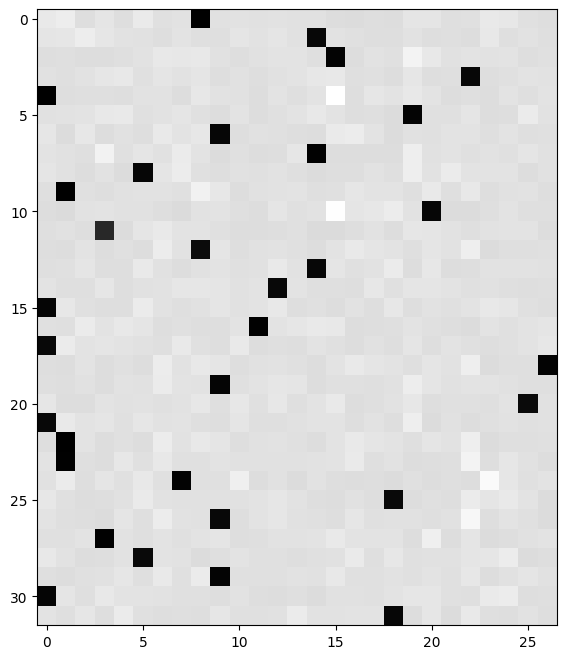

In [133]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='gray')

### Exercise 3

In [134]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [135]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
# bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5)
# gain* ((n-1)*D^2-N)/(n*D^3)

# yi is hpreact [32, 64] 32 inputs 64 neurons
# and Summation over j Sum(dL/dyj) means over batch -> dhpreact)
# why over batch

dhprebn = ((bngain*bnvar_inv)/n) * (n*dhpreact - dhpreact.sum(dim=0, keepdim=True) - ((n/(n-1)) * bnraw * (dhpreact*bnraw).sum(dim=0, keepdim=True)))
# [32, 64]
# -----------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


### Exercise 4

In [144]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for run in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    #loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # ---------------------------------------------
    dlogits = logits.exp()/logits.exp().sum(dim=1, keepdim=True)
    dlogits[range(n), Yb] -= 1.0
    dlogits *= (1/n)

    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(dim=0)
    dhpreact = (1-h**2) * dh
    dbngain = (bnraw * dhpreact).sum(dim=0, keepdim=True)
    dbnbias = dhpreact.sum(dim=0, keepdim=True)
    dhprebn = ((bngain*bnvar_inv)/n) * (n*dhpreact - dhpreact.sum(dim=0, keepdim=True) - ((n/(n-1)) * bnraw * (dhpreact*bnraw).sum(dim=0, keepdim=True)))
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(dim=0)
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for i in range(Xb.shape[0]):
      for j in range(Xb.shape[1]): # Gives row indices of C
        idx = Xb[i,j] # X[0,2] = 4
        dC[idx] += demb[i, j] # gives row in C

    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if run % 10000 == 0: # print every once in a while
      print(f'{run:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #if run >= 100: # TODO: delete early breaking when you're ready to train the full net
    #  break

12297
      0/ 200000: 3.7783
  10000/ 200000: 2.2071
  20000/ 200000: 2.3718
  30000/ 200000: 2.4764
  40000/ 200000: 2.0600
  50000/ 200000: 2.4417
  60000/ 200000: 2.3793
  70000/ 200000: 1.9999
  80000/ 200000: 2.3331
  90000/ 200000: 2.1532
 100000/ 200000: 1.9684
 110000/ 200000: 2.5367
 120000/ 200000: 1.9197
 130000/ 200000: 2.3103
 140000/ 200000: 2.3165
 150000/ 200000: 2.3066
 160000/ 200000: 1.9351
 170000/ 200000: 1.8709
 180000/ 200000: 2.1056
 190000/ 200000: 1.8750


In [141]:
# useful for checking your gradients
#for p,g in zip(parameters, grads):
#  cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | maxdiff: 1.210719347000122e-08
(30, 200)       | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(200,)          | exact: False | approximate: True  | maxdiff: 5.3551048040390015e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 2.2351741790771484e-08
(27,)           | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(1, 200)        | exact: False | approximate: True  | maxdiff: 2.561137080192566e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


In [148]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [149]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1205971240997314
val 2.163750171661377


In [150]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahzabelle.
khyimri.
reetlanica.
sky.
mahnen.
den.
archireei.
nellara.
chriha.
kaleigh.
ham.
jocn.
quint.
shon.
marian.
quinte.
madiaryn.
kai.
eklin.
abee.
